# Image Dataset and DataLoader Setup

This notebook contains the necessary imports, data downloads, transforms, and DataLoaders copied from `pytorch_custom_dataset.ipynb` to prepare the image data for a new model.

In [257]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image
import requests
import zipfile
from pathlib import Path
import os

# Device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [258]:
# Setup path to a datafolder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder does not exist, download and prepare it
if image_path.is_dir():
    print(f"{image_path} Directory already exists... skipping download")
else:
    print(f"{image_path} does not exist creating one")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download the dataset
    zip_filepath = data_path / "pizza_steak_sushi.zip"
    with open(zip_filepath, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza steak sushi data...")
        f.write(request.content)
        
    # Unzip pizza steak sushi file
    with zipfile.ZipFile(zip_filepath, "r") as zip_ref:
        print("Unzipping pizza steak sushi data...")
        zip_ref.extractall(image_path)

data\pizza_steak_sushi Directory already exists... skipping download


In [259]:
# Setup train and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [260]:
# Write a transform for the images
data_transform = transforms.Compose([
    # Resize our images to 64 * 64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Convert to Tensor
    transforms.ToTensor()
])

In [261]:
# Turn train and test datasets into ImageFolder datasets
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)

class_names = train_data.classes
class_dict = train_data.class_to_idx

print(f"Train data length: {len(train_data)}")
print(f"Test data length: {len(test_data)}")
print(f"Class Names: {class_names}")

Train data length: 225
Test data length: 75
Class Names: ['pizza', 'steak', 'sushi']


In [262]:
# Turn datasets into DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0  # 0 is recommended for compatibility on Windows

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

print(f"Train Dataloader batches: {len(train_dataloader)}")
print(f"Test Dataloader batches: {len(test_dataloader)}")

Train Dataloader batches: 8
Test Dataloader batches: 3


In [263]:
# Retrieve a single batch to verify shapes
img_batch, label_batch = next(iter(train_dataloader))
print(f"Image batch shape: {img_batch.shape} -> [batch_size, color_channels, height, width]")
print(f"Label batch shape: {label_batch.shape}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label batch shape: torch.Size([32])


## Custom Dataset and Custom DataLoader Setup

Below, we define a custom subclass of `torch.utils.data.Dataset` called `ImageFolderCustom` to replicate the functionality of `torchvision.datasets.ImageFolder` manually, along with its corresponding DataLoaders.

In [264]:
def find_classes(directory: str) -> tuple[list[str], dict[str, int]]:
    """
    Finds the class folder names in a target directory.
    """
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    # 2. Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Could not find any classes in the {directory}\nPlease check file structure")
        
    # 3. Create a dictionary of index labels
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

In [265]:
class ImageFolderCustom(Dataset):
    def __init__(self, target_dir: str, transform=None):
        self.paths = list(Path(target_dir).glob("*/*.jpg"))
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(target_dir)

    # Create a function to load images
    def load_image(self, index: int) -> Image.Image:
        """
        Opens an image via a path and returns it
        """
        image_path = self.paths[index]
        return Image.open(image_path)

    # Overwrite __len__()
    def __len__(self) -> int:
        "Returns the total number of samples"
        return len(self.paths)

    # Overwrite __getitem__() method to return a particular sample
    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X and Y)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name  # Expects path in format: data_folder/class_name/image.jpg
        class_idx = self.class_to_idx[class_name]
        
        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx  # Return untransformed image and label

In [266]:
# Create transforms for Custom Dataset
train_transforms_custom = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms_custom = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [267]:
# Create instances of ImageFolderCustom
train_data_custom = ImageFolderCustom(target_dir=train_dir, transform=train_transforms_custom)
test_data_custom = ImageFolderCustom(target_dir=test_dir, transform=test_transforms_custom)

print(f"Custom Train data classes: {train_data_custom.classes}")
print(f"Custom Train data class to idx: {train_data_custom.class_to_idx}")

Custom Train data classes: ['pizza', 'steak', 'sushi']
Custom Train data class to idx: {'pizza': 0, 'steak': 1, 'sushi': 2}


In [268]:
# Create Dataloaders from Custom Dataset instances
BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader_custom = DataLoader(
    dataset=train_data_custom,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x1ca05cfba90>,
 <torch.utils.data.dataloader.DataLoader at 0x1c9ca86de70>)

In [269]:
# Retrieve a single batch to verify shapes from Custom DataLoader
img_custom_batch, label_custom_batch = next(iter(train_dataloader_custom))
print(f"Custom Image batch shape: {img_custom_batch.shape} -> [batch_size, color_channels, height, width]")
print(f"Custom Label batch shape: {label_custom_batch.shape}")

Custom Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Custom Label batch shape: torch.Size([32])


### 7.1 Creating a cnn of TinyVGG architecture

In [270]:
class TinyVGG(nn.Module):
    """
        Model architecture copying TinyVgg architecture from CNN explainer
    """
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,
            kernel_size=3,stride= 1 , padding= 1),
            
            nn.ReLU(),
            
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
            kernel_size=3, stride=1 ,padding=1   ),

            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
            

        self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
        kernel_size=3,stride= 1 , padding= 1 ),
        
        nn.ReLU(),
        
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
        kernel_size=3, stride=1 ,padding=1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,out_features=output_shape    )
        )
    def forward(self,x):
        x = self.conv_block_1(x)
        #print(x.shape)
        x = self.conv_block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x
        #return self.classifier(self.conv_block_2(self.conv_block_1(x)))
        #https://horace.io/brrr_intro.html

In [271]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,hidden_units=20,output_shape= len(class_names)).to(device)

model_0


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5120, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass using a single image

In [272]:
from torchvision import transforms

# 1. Create a transform pipeline for the training data
train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)), # Resize images to 64x64
    transforms.ToTensor()             # Convert PIL images to PyTorch Tensors (and scale pixels to 0-1)
])

# 2. Create a transform pipeline for the testing data
test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)), # Resize images to 64x64
    transforms.ToTensor()             # Convert PIL images to PyTorch Tensors
])

print(f"Train transforms:\n{train_transforms}")
print(f"Test transforms:\n{test_transforms}")

Train transforms:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Test transforms:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [273]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. Create the "Simple" Datasets using PyTorch's built-in ImageFolder
train_data_simple = datasets.ImageFolder(root=train_dir, 
                                         transform=train_transforms)

test_data_simple = datasets.ImageFolder(root=test_dir, 
                                        transform=test_transforms)

# 2. Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = 0 # Keeps it safe for Windows Jupyter execution

# 3. Create the DataLoaders
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

print(f"Train dataloader: {train_dataloader_simple}")
print(f"Test dataloader: {test_dataloader_simple}")

Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x000001CA02FD96C0>
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x000001CA02FD9300>


In [274]:
image_batch , label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape
image_batch,label_batch = image_batch.to(device) , label_batch.to(device)


In [275]:
#Try a forward pass
model_0(image_batch)

tensor([[ 7.7948e-03,  3.4903e-02, -1.3499e-03],
        [ 5.8434e-03,  3.8860e-02, -1.0296e-03],
        [ 4.3859e-03,  3.5500e-02, -8.9738e-04],
        [ 4.0914e-03,  3.8638e-02,  3.7058e-03],
        [ 5.8356e-03,  3.7182e-02, -1.9974e-03],
        [ 4.6681e-03,  4.0596e-02, -1.1663e-03],
        [ 5.1903e-03,  3.5727e-02,  2.3738e-04],
        [ 4.7419e-03,  3.7041e-02,  1.5231e-04],
        [ 3.5429e-03,  3.6014e-02, -6.0883e-04],
        [ 7.4736e-03,  4.0868e-02,  3.7840e-04],
        [ 4.8275e-03,  3.6168e-02,  2.7013e-04],
        [ 4.8530e-03,  3.1737e-02, -1.2688e-03],
        [ 6.9320e-03,  3.8144e-02,  6.0058e-04],
        [ 5.6031e-03,  3.4854e-02,  1.5970e-03],
        [ 4.3199e-03,  3.7090e-02,  2.6225e-03],
        [ 5.9665e-03,  4.0117e-02, -6.3074e-04],
        [ 6.3533e-03,  3.6741e-02,  6.6295e-04],
        [ 7.5009e-03,  3.8141e-02, -3.3231e-03],
        [ 7.1865e-03,  4.0675e-02, -2.9777e-04],
        [ 6.4286e-03,  3.9737e-02, -8.8401e-04],
        [ 6.4507e-03

In [276]:
10*16*16


2560

### 7.4 Using `torchinfo` to get an idea of the shapes going through our model

In [277]:
from torchinfo import summary
summary(model_0,input_size= [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 20, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 20, 64, 64]           560
│    └─ReLU: 2-2                         [1, 20, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 20, 64, 64]           3,620
│    └─ReLU: 2-4                         [1, 20, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 20, 32, 32]           --
├─Sequential: 1-2                        [1, 20, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 20, 32, 32]           3,620
│    └─ReLU: 2-7                         [1, 20, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 20, 32, 32]           3,620
│    └─ReLU: 2-9                         [1, 20, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 20, 16, 16]           --
├─Seq

### 7.5 Create train and test loops functions

`train_step()` - Takes in a model and dataloader and trains the model on the dataloader

`test_step()` - Takes in a model and a dataloader and tests the model on the dataloader


In [278]:
from train_test import test_step , train_step,eval_model
from helper_function import accuracy_fn,print_train_time
from tqdm.auto import tqdm

#Setting up loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_0.parameters(),lr = 0.1)



In [279]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [280]:
device

'cuda'

In [281]:

from tqdm.auto import tqdm
torch.manual_seed(42)
from helper_function import print_train_time
from timeit import default_timer as timer 

def train_step(model:torch.nn.Module,dataloader : torch.utils.data.DataLoader,
                loss_fn  : torch.nn.Module ,optimizer : torch.optim.Optimizer,device = device):
    #Put the model in train mode
    model_0.train()
    #Setup the train loss and train accuracy values
    train_loss,train_acc= 0,0
    
    for batch,(X,y) in enumerate(dataloader):
        #Send the data to the target data
        X,y = X.to(device),y.to(device)
        #Forward pass
        y_pred = model_0(X)
        #Calculate the loss 
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        

        optimizer.zero_grad()

        loss.backward()
        
        optimizer.step()

        #Calculate the accumulated accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc = (y_pred_class == y ).sum().item() / len(y_pred)

    #Adjust metrics to get avrage loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss , train_acc
    






In [282]:
#Create test step
def test_step(model:torch.nn.Module,dataloader : torch.utils.data.DataLoader,
                loss_fn  : torch.nn.Module, device = device):
    #put model in eval mode
    model.eval()

    #Setup test loss and test accuracy values
    test_loss,test_acc = 0,0
    #Turn on inference mode
    with torch.inference_mode():
        #Loop through dataloader batches
        for batch,(X,y) in enumerate(dataloader):
            #Send the data to target device
            X ,y = X.to(device) , y.to(device)

            #Forward pass
            test_pred_logits = model(X)

            #Calcualte the loss
            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()

            #Calculte the accruacy
            test_pred_labels = test_pred_logits.argmax(dim = 1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    #Adjust metircs to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss,test_acc
    



### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`


In [283]:
from tqdm.auto import tqdm

#1.Create a train function that takes in various model parameters + optimizer + dataloaders + loss function
def train(model : torch.nn.Module,train_dataloader : torch.utils.data.DataLoader,test_dataloader : torch.utils.data.DataLoader,
        optimizer:torch.optim.Optimizer,loss_fn : torch.nn.Module = nn.CrossEntropyLoss(),epochs:int = 5,device = device ):
    #2. Create empty results dictionary 
    results = {'test_acc':[],
                'test_loss':[],
                'train_acc':[],
                'train_loss':[]}

                
    for epoch in tqdm(range(epochs)):
        train_loss , train_acc = train_step(model=model,
                                            dataloader = train_dataloader,
                                            loss_fn = loss_fn,
                                            optimizer = optimizer
                                            ,device = device)
        test_loss,test_acc = test_step(model = model,dataloader=test_dataloader,
                                        loss_fn = loss_fn,device = device)
        #Printing out what is happening
        print(f"Epoch : {epoch+1} | Train loss : {train_loss:.4f} | Train acc : {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        #Update the results dictionary
        results["test_acc"].append(test_acc)
        results["test_loss"].append(test_loss)
        
        results["train_acc"].append(train_acc)
        results["train_loss"].append(train_loss)
        

    return results

### 7.7 Train and evalvuate model_0

In [284]:
#Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#Set number of epochs
EPOCHS = 20
model_0 = TinyVGG(input_shape= 3,hidden_units = 10 ,output_shape = len(train_data.classes)).to(device)
#Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),lr = 0.001)

#Start the timer
from timeit import default_timer as timer 
start_time = timer()

#Train model_0
model_0_results = train(model= model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        epochs = EPOCHS)

#End the timer and calculate training time
end_time = timer()
print(f"Total trianing time : {end_time - start_time:.3f} seconds")


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 1 | Train loss : 1.1078 | Train acc : 0.0000 | Test loss: 1.1362 | Test acc: 0.2604
Epoch : 2 | Train loss : 1.0846 | Train acc : 0.1250 | Test loss: 1.1621 | Test acc: 0.1979
Epoch : 3 | Train loss : 1.1154 | Train acc : 0.0000 | Test loss: 1.1698 | Test acc: 0.1979
Epoch : 4 | Train loss : 1.0983 | Train acc : 0.1250 | Test loss: 1.1351 | Test acc: 0.1979
Epoch : 5 | Train loss : 1.0991 | Train acc : 0.0000 | Test loss: 1.1433 | Test acc: 0.1979
Epoch : 6 | Train loss : 1.0952 | Train acc : 0.0000 | Test loss: 1.1480 | Test acc: 0.2604
Epoch : 7 | Train loss : 1.1189 | Train acc : 0.0000 | Test loss: 1.1426 | Test acc: 0.3125
Epoch : 8 | Train loss : 1.1019 | Train acc : 0.0000 | Test loss: 1.1053 | Test acc: 0.2188
Epoch : 9 | Train loss : 1.0880 | Train acc : 0.1250 | Test loss: 1.0651 | Test acc: 0.5417
Epoch : 10 | Train loss : 1.0631 | Train acc : 0.1250 | Test loss: 1.0117 | Test acc: 0.5417
Epoch : 11 | Train loss : 1.0288 | Train acc : 0.1250 | Test loss: 0.9681 | Tes

### 7.8 Plot the loss curvves of model_0

A **Loss curve** tracks the model's progress overtime

In [285]:
model_0_results.keys(),model_0_results

(dict_keys(['test_acc', 'test_loss', 'train_acc', 'train_loss']),
 {'test_acc': [0.2604166666666667,
   0.19791666666666666,
   0.19791666666666666,
   0.19791666666666666,
   0.19791666666666666,
   0.2604166666666667,
   0.3125,
   0.21875,
   0.5416666666666666,
   0.5416666666666666,
   0.6041666666666666,
   0.40246212121212127,
   0.4431818181818182,
   0.59375,
   0.5748106060606061,
   0.3835227272727273,
   0.36174242424242425,
   0.40246212121212127,
   0.524621212121212,
   0.45359848484848486],
  'test_loss': [1.1362135410308838,
   1.1621214946111043,
   1.169783314069112,
   1.1350627740224202,
   1.143312891324361,
   1.147958238919576,
   1.1425978740056355,
   1.1053274075190227,
   1.0651394128799438,
   1.0117074648539226,
   0.9680512348810831,
   1.0677764018376668,
   0.9786400397618612,
   0.9192760586738586,
   0.9681822061538696,
   1.051404555638631,
   1.0115050077438354,
   1.0079743067423503,
   0.9526186982790629,
   1.1402120192845662],
  'train_acc': [0.

In [288]:
import matplotlib.pyplot as plt
def plot_losscurves(results : dict[str,list[float]]):
    """Plots training curves of results dictionary """

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    #Get the accuracy values of the results dictionary (training and testing )
    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    #Count epochs
    epochs = range(len(results['train_loss']))
    #Setup plot
    plt.figure(figsize = (15,7))
    #Plot the loss
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,label='Train_loss')
    plt.plot(epochs,test_loss,label = 'Test_loss')
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    #Plot the accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs,train_accuracy,label= "train_accuracy")
    plt.plot(epochs,test_accuracy,label = "test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend();

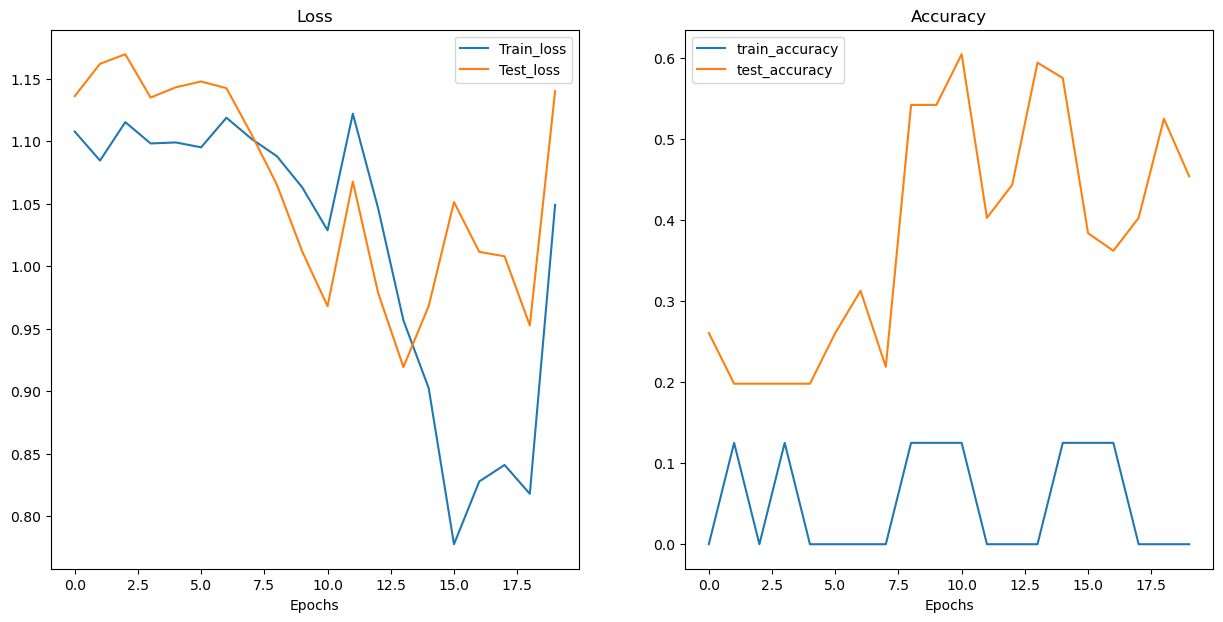

In [289]:
plot_losscurves(model_0_results)